Loading processed data...
Training set shape: (4000, 7)
Test set shape: (1000, 7)
Base Complaint Rate: 9.80%

--- Training Model 1: Logistic Regression ---
Best LR Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}

--- Training Model 2: Random Forest ---
Best RF Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

          MODEL EVALUATION RESULTS          

[Logistic Regression]
ROC-AUC Score: 0.9173
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       902
           1       0.33      0.84      0.47        98

    accuracy                           0.82      1000
   macro avg       0.65      0.83      0.68      1000
weighted avg       0.92      0.82      0.85      1000

[Random Forest]
ROC-AUC Score: 0.9172
              precision    recall  f1-score   support

           0       1.00      0.72      0.83       902
           1       0.27     

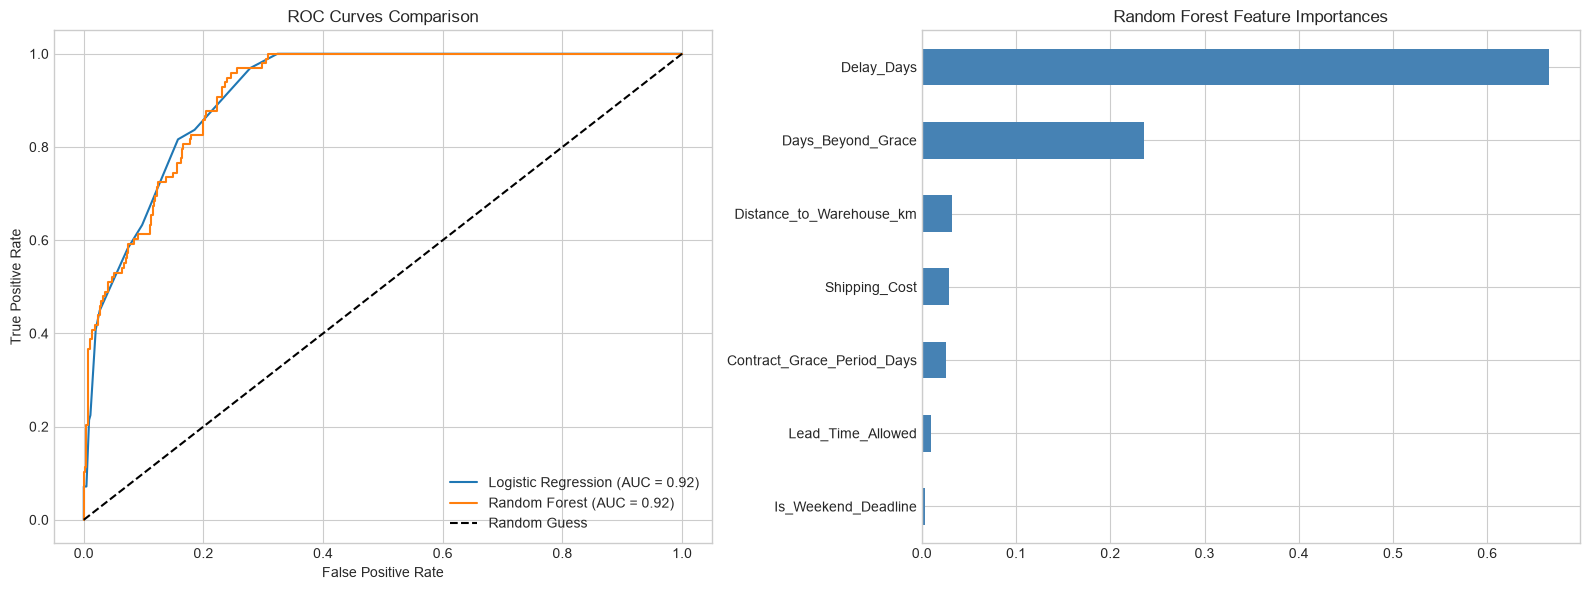

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings

# Ignore convergence warnings for cleaner output during GridSearch
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 1. Data Preparation & Splitting
# ==========================================
print("Loading processed data...")
df = pd.read_csv('processed_b2b_delivery_data.csv')

# Define features (X) and target (y)
# We drop IDs as they hold no predictive value for new orders
X = df.drop(columns=['Order_ID', 'Customer_ID', 'Is_Late_Complaint'])
y = df['Is_Late_Complaint']

# Train-Test Split (Stratify is crucial here due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Base Complaint Rate: {y.mean():.2%}\n")

# Standardize features (Critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. Model 1: Logistic Regression (The Interpretable Baseline)
# ==========================================
print("--- Training Model 1: Logistic Regression ---")

# Define parameter grid for tuning
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],            # Regularization strength
    'penalty': ['l1', 'l2'],            # L1 (Lasso) and L2 (Ridge)
    'solver': ['liblinear'],            # Good solver for small datasets & L1
    'class_weight': ['balanced', None]  # Handle imbalanced complaints
}

log_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=log_param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='roc_auc',        # Optimize for AUC, not accuracy
    n_jobs=-1
)

log_grid.fit(X_train_scaled, y_train)

best_log_model = log_grid.best_estimator_
print(f"Best LR Parameters: {log_grid.best_params_}")

# ==========================================
# 3. Model 2: Random Forest (The Non-Linear Powerhouse)
# ==========================================
print("\n--- Training Model 2: Random Forest ---")

# Define parameter grid for tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train) # Note: RF doesn't strictly need scaled data

best_rf_model = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")

# ==========================================
# 4. Model Evaluation & Comparison
# ==========================================
print("\n==========================================")
print("          MODEL EVALUATION RESULTS          ")
print("==========================================\n")

models = {
    "Logistic Regression": (best_log_model, X_test_scaled),
    "Random Forest": (best_rf_model, X_test)
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, (model, X_eval) in models.items():
    # Predictions
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"[{name}]")
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    
    # Feature Importance (For Random Forest)
    if name == "Random Forest":
        importances = pd.Series(model.feature_importances_, index=X.columns)
        importances.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='steelblue')
        axes[1].set_title('Random Forest Feature Importances')

# Formatting ROC Plot
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves Comparison')
axes[0].legend()

plt.tight_layout()
plt.show()